# Smart Expense Categorization — Day 16

**Mehar Ali | HisabDo AI/ML Team**

Goal: Build a balanced baseline classifier using TF-IDF + Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
from pathlib import Path
RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
# Find the repository's dataset even when Jupyter starts in a subdirectory.
dataset_path = next(
    (directory / "data" / "expense_data.csv"
     for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "data" / "expense_data.csv").is_file()),
    None,
)
if dataset_path is None:
    raise FileNotFoundError("Could not find data/expense_data.csv. Open the notebook from this repository.")

repository_root = dataset_path.parent.parent
model_path = repository_root / "model" / "expense_categorization_pipeline.pkl"

df = pd.read_csv(dataset_path)
df.head()

,description,amount,category
0,university tuition this week,28000,Education
1,bought vegetables near home,3150,Groceries
2,bought notebook for class using cash,8550,Education
3,gas charges,14000,Utilities
4,bus fare,8850,Transport


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nCategory counts:")
print(df["category"].value_counts().sort_index())

Dataset shape: (500, 3)

Missing values:
description    0
amount         0
category       0
dtype: int64

Category counts:
category
Bills            50
Education        50
Entertainment    50
Food             50
Groceries        50
Healthcare       50
Other            50
Shopping         50
Transport        50
Utilities        50
Name: count, dtype: int64


## 2. Check Class Balance

Each category has the same number of records: True


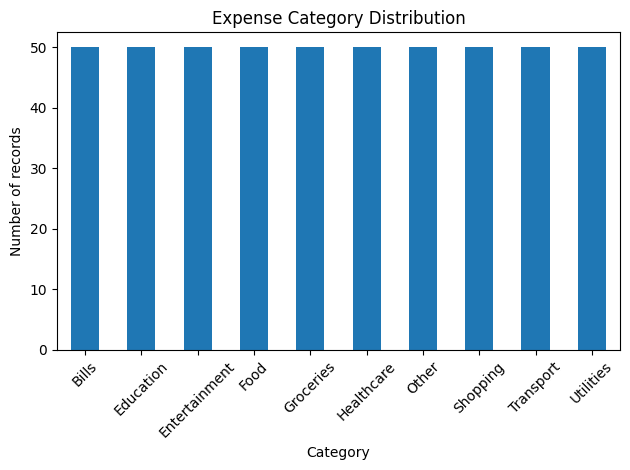

In [4]:
class_counts = df["category"].value_counts().sort_index()
print("Each category has the same number of records:", class_counts.nunique() == 1)
class_counts.plot(kind="bar", title="Expense Category Distribution")
plt.xlabel("Category"); plt.ylabel("Number of records")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 3. Prepare Features and Target

The Day 16 baseline uses the expense description as the text feature. The amount remains available for future feature engineering.

In [6]:
X = df["description"].astype(str)
y = df["category"].astype(str)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500,)
y shape: (500,)


## 4. Train/Test Split

80% is used for training and 20% for testing. `stratify=y` preserves category proportions.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400,)
X_test: (100,)
y_train: (400,)
y_test: (100,)


## 5. Build TF-IDF + Logistic Regression Pipeline

In [8]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


## 6. Evaluate the Model

In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        10
    Education       1.00      1.00      1.00        10
Entertainment       1.00      1.00      1.00        10
         Food       1.00      1.00      1.00        10
    Groceries       1.00      1.00      1.00        10
   Healthcare       1.00      1.00      1.00        10
        Other       1.00      1.00      1.00        10
     Shopping       1.00      1.00      1.00        10
    Transport       1.00      1.00      1.00        10
    Utilities       1.00      1.00      1.00        10

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100



## 7. Confusion Matrix

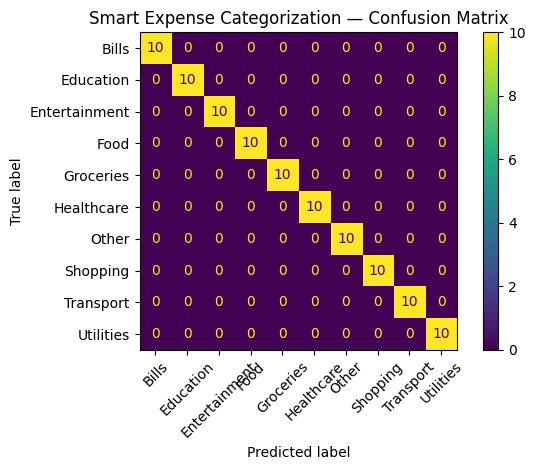

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Smart Expense Categorization — Confusion Matrix")
plt.tight_layout(); plt.show()

## 8. Test New Expenses

In [11]:
new_expenses = [
    "Bought groceries from Imtiaz","Petrol from PSO","Electricity bill payment",
    "Restaurant dinner","Bought medicine from pharmacy","Bought a pair of shoes",
    "Movie ticket","Python programming course fee","Internet bill payment",
    "Miscellaneous household purchase"
]
predictions = model.predict(new_expenses)
probabilities = model.predict_proba(new_expenses)
results = pd.DataFrame({
    "description": new_expenses,
    "predicted_category": predictions,
    "confidence": np.round(probabilities.max(axis=1), 3)
})
results

,description,predicted_category,confidence
0,Bought groceries from Imtiaz,Shopping,0.516
1,Petrol from PSO,Transport,0.388
2,Electricity bill payment,Utilities,0.661
3,Restaurant dinner,Food,0.627
4,Bought medicine from pharmacy,Healthcare,0.539
5,Bought a pair of shoes,Shopping,0.467
6,Movie ticket,Entertainment,0.690
7,Python programming course fee,Education,0.772
8,Internet bill payment,Bills,0.626
9,Miscellaneous household purchase,Other,0.754


## 9. Save the Trained Model

In [12]:
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"Saved: {model_path}")

Saved: d:\BootCamp\week3\hisabdo-webapp-ai\model\expense_categorization_pipeline.pkl


## 10. Reload and Predict

In [13]:
loaded_model = joblib.load(model_path)
text = "Bought groceries from supermarket"
prediction = loaded_model.predict([text])[0]
confidence = loaded_model.predict_proba([text]).max()
print("Description:", text)
print("Predicted category:", prediction)
print("Confidence:", round(confidence, 3))

Description: Bought groceries from supermarket
Predicted category: Shopping
Confidence: 0.516


## 11. Conclusion

This Day 16 POC trains and evaluates a balanced multi-class expense categorization model using TF-IDF and Logistic Regression. The dataset is synthetic and intended for development/testing only. Production performance requires representative, authorized and anonymized real-world data.